# CIS164 Final Project Notebook 


# Research Questions

**Research Question**
- Which type of vehicle is involved in the most fatal crashes?

**Why this matters**
People may be interested in knowing what sorts of vehicles are the least safe to drive statistically or at the very least, which vehicle types to avoid the most on the road.

**Research Question**
- Is a drunk driver more likely to kill themselves or another driver?

**Why this matters**
Driving drunk is unsafe. Despite knowing this, people still drive drunk which many know is at a risk to themselves. It is important to present a visual into how much more dangerous it really is, both to the driver and to everyone else on the road.

**Research Question**
- Are people who don't wear seatbelts more likely to die in a fatal crash

**Why this matters**
This question has already been determined. In fact, it has been known to be true that people who don't wear seatbelts are more likely to die in a crash. However, many people still don't wear seatbelts. This question is here for those people so that they may clearly see the effects of not wearing a seatbelt.


# Dataset Description

**Dataset Source**
- National Highway Traffic Safety Administration (NHTSA)

The dataset provided by the NHTSA represents all of the accident data from all 52 states in the United States of America. This includes data on who was killed in the crash, the type of vehicle, the blood alcohol content of the drivers, whether or not they were wearing restraints, and a variety of other data.

**Key Variables**
- `State`
- `killed_driver_bac`
- `surviving_driver_bac`
- `vehicle_type`
- `restraint_use`
- `fatality number`
- `fatality percentage`

These variables each take up more than one column of data, but are the general variables of importance for this project.

**Limitations**
- There are 3 missing values in the data
- There is no easy way to replace those values however, 3 out of 1024 data values is negligible 


# Import Libraries

We are using **pandas** for data manipulation and cleaning, **numpy** for statistical operations, and **matplotlib** and **seaborn** for data visualizations and statistical tests.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

The dataset we loaded was from an excel file. We previewed the dataset **vehicle** to ensure that it loaded correctly. The rest of the data was also previewed, but the code for that was removed from this final report to reduce clutter. The comments in the cell below represent the new names of the dataframes after we cleaned them. We will explain how we cleaned them in the next portion of the report. 


In [2]:
event = pd.read_excel("Total Fatal Crashes by Event.xlsx") #Cleaned: crashes_by_event
road_crashes =pd.read_excel("Fatal Crashes by Road.xlsx") #Cleaned: total_road_crashes
fatalities = pd.read_excel("Fatalities.xlsx") #Cleaned: fatalities_by_state
person_killed = pd.read_excel("Person Killed.xlsx") #Cleaned: type_person_killed
road_deaths = pd.read_excel("Total Deaths by Road.xlsx") #Cleaned: total_road_deaths
age = pd.read_excel("Victim Age.xlsx") #Cleaned: victim_age
pedestrians = pd.read_excel("Pedestrian Deaths.xlsx") #Cleaned: pedestrian_deaths
killed_driver_bac = pd.read_excel("Killed Driver BAC.xlsx") #Cleaned: driver_victim_bac
crash_driver_bac = pd.read_excel("Fatal Crash Driver BAC.xlsx") #Cleaned: all_driver_bac
restraint_use = pd.read_excel("Restraint Use Data.xlsx") #Cleaned: restraints
rollover = pd.read_excel("Rollover Data.xlsx") #Cleaned: rollovers
surviving_driver_bac = pd.read_excel("Surviving Driver BAC.xlsx") #Cleaned: living_driver_bac
vehicle = pd.read_excel("Vehicle Type.xlsx") #Cleaned: vehicles
vmt  = pd.read_excel("VMT.xlsx") #Cleaned: vmt2
vehicle.head()

,Unnamed: 0,Unnamed: 1,Vehicle Type,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12,Unnamed: 13,Unnamed: 14,Unnamed: 15,Unnamed: 16
0,NaN,NaN,Passenger Cars,NaN,Light Trucks,NaN,Large Trucks,NaN,Buses,NaN,Other Vehicles/Unknown,NaN,Total,NaN,Motorcycles,NaN,Total Occupants Killed
1,State,Number,Percent,Number,Percent,Number,Percent,Number,Percent,Number,Percent,Number,Percent,Number,Percent,Number,Percent
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Alabama,335,40,364,43.4,29,3.5,0,0,16,1.9,744,88.8,94,11.2,838,100
4,Alaska,13,27.1,23,47.9,1,2.1,0,0,3,6.3,40,83.3,8,16.7,48,100


# Data Cleaning

After converting the excel files into dataframes, the first few rows of each dataframe were a mismatched combination of the file labeling system. In other words, the file column names were split into several pieces, amongst several different rows. Thus, we had to fix the column names and remove the first few rows of the data. There was a lot of column names, so to relabel them in a meaningful way, we used a string of code to combine all of the pieces into the full column names, and then reassigned those names to the columns. A secondary problem stemming from the column names having been inserted into the rows of the dataframe was that almost all of our columns were labeled as objects, including the numeric ones. Therefore we also converted all of the columns that were meant to be numeric to numeric data. Lastly, we then created one file containing all of this data. We had to drop overlapping columns to do so. 


In [3]:
event2 = event.iloc[1:].reset_index(drop=True)
for index, val in enumerate(event2.iloc[0]):
    if pd.isna(val):
        event2.iloc[0, index] = event2.iloc[0, index+1]


event2.iloc[2] = event2.iloc[0]+" " + event2.iloc[1]
event2.iloc[2,0] = "State"
event2.columns = event2.iloc[2]
event2.columns.name = None
crashes_by_event = event2.iloc[3:].reset_index(drop=True)
crashes_by_event = crashes_by_event.apply(pd.to_numeric, errors = "ignore")
crashes_by_event8 = crashes_by_event.drop(columns = ["Other Number", "Other Percent", "Unknown Number", "Unknown Percent"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\4282668067.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  crashes_by_event = crashes_by_event.apply(pd.to_numeric, errors = "ignore")


In [4]:
road_crashes.columns = road_crashes.iloc[2] + " Crashes"
road_crashes.columns.name = None
total_road_crashes = road_crashes.iloc[4:].reset_index(drop=True)
total_road_crashes = total_road_crashes.apply(pd.to_numeric, errors = "ignore")
total_road_crashes8 = total_road_crashes.drop(columns=["State Crashes"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\579640847.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  total_road_crashes = total_road_crashes.apply(pd.to_numeric, errors = "ignore")


In [5]:
person_killed2 = person_killed.copy()
for index in range(len(person_killed.columns)-1, 6, -1):
    person_killed2.iloc[0, index] = person_killed.iloc[0, index-2]

person_killed2.iloc[0, 6] = "Motorcyclist"
person_killed2.iloc[0,0] = "State"

for index, val in enumerate(person_killed2.iloc[0]):
    if pd.isna(val):
        person_killed2.iloc[0, index] = person_killed2.iloc[0, index+1]
person_killed2.iloc[2] = person_killed2.iloc[0]+ " " + person_killed2.iloc[1]

person_killed2.columns = person_killed2.iloc[2]
person_killed2.columns.name = None
type_person_killed = person_killed2.iloc[3:].reset_index(drop=True)
type_person_killed.rename(columns = {"State State": "State"}, inplace=True)
type_person_killed = type_person_killed.apply(pd.to_numeric, errors = "ignore")
type_person_killed8 = type_person_killed.drop(columns = ["State", "Other/Unknown Number", "Other/Unknown Percent"])
type_person_killed8 = type_person_killed8[type_person_killed8.columns.dropna()]

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\3972875291.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Total Killed' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  person_killed2.iloc[0, index] = person_killed.iloc[0, index-2]
C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\3972875291.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Total Killed' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  person_killed2.iloc[0, index] = person_killed2.iloc[0, index+1]
C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\3972875291.py:17: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  type_person_killed = type_person_killed

In [6]:
road_deaths.columns = road_deaths.iloc[2] + " Deaths"
road_deaths.columns.name = None
total_road_deaths = road_deaths.iloc[4:].reset_index(drop=True)
total_road_deaths = total_road_deaths.apply(pd.to_numeric, errors = "ignore")
total_road_deaths8 = total_road_deaths.drop(columns=["State Deaths"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\2288010528.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  total_road_deaths = total_road_deaths.apply(pd.to_numeric, errors = "ignore")


In [7]:
fatalities_by_state = fatalities.iloc[1:].reset_index(drop=True)
fatalities_by_state8 = fatalities_by_state.drop(columns=["State"])

In [8]:
age.columns = "Age " + age.iloc[0]
age.columns.name = None
victim_age = age.iloc[2:].reset_index(drop=True)
victim_age = victim_age.apply(pd.to_numeric, errors = "ignore")
victim_age8 = victim_age.drop(columns = ["Age State"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\4019118734.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  victim_age = victim_age.apply(pd.to_numeric, errors = "ignore")


In [9]:
pedestrian_deaths = pedestrians.iloc[1:].sort_values(by= "State").reset_index(drop=True)
pedestrian_deaths = pedestrian_deaths[["State", "Pedestrians Killed", "Population (Thousands)", "Pedestrian Fatality Rate per 100,000 Population"]]
pedestrian_deaths = pedestrian_deaths.apply(pd.to_numeric, errors = "ignore")
pedestrian_deaths8 = pedestrian_deaths.drop(columns = ["State"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\1962759674.py:3: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  pedestrian_deaths = pedestrian_deaths.apply(pd.to_numeric, errors = "ignore")


In [10]:
killed_driver_bac2 = killed_driver_bac.copy()

for i, val in enumerate(killed_driver_bac2.iloc[0]):
    if pd.isna(val):
        killed_driver_bac2.iloc[0, i] = killed_driver_bac.iloc[0, i+1]

killed_driver_bac2.iloc[2] = "Victim " + killed_driver_bac2.iloc[0] + " " + killed_driver_bac2.iloc[1]
killed_driver_bac2.iloc[2, 0] = "State"
killed_driver_bac2.columns = killed_driver_bac2.iloc[2]
killed_driver_bac2.columns.name = None

driver_victim_bac = killed_driver_bac2.iloc[3:].reset_index(drop=True)
driver_victim_bac = driver_victim_bac.apply(pd.to_numeric, errors = "ignore")
driver_victim_bac8 = driver_victim_bac.drop(columns = {"Victim Total Drivers Killed Percent", "State"})

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\2097505884.py:13: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  driver_victim_bac = driver_victim_bac.apply(pd.to_numeric, errors = "ignore")


In [11]:
cdb = crash_driver_bac.copy()
for i, val in enumerate(crash_driver_bac.iloc[0]):
    if pd.isna(val):
        cdb.iloc[0, i] = crash_driver_bac.iloc[0, i+1]

cdb.iloc[2] = "All " + cdb.iloc[0] +" " + cdb.iloc[1]
cdb.iloc[2, 0] = "State"
cdb.columns = cdb.iloc[2]
cdb.columns.name = None

all_driver_bac = cdb.iloc[3:].reset_index(drop=True)
all_driver_bac = all_driver_bac.apply(pd.to_numeric, errors = "ignore")
all_driver_bac8 = all_driver_bac.drop(columns = {"All Total Drivers Involved in Fatal Crashes Percent", "State"})

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\4227290427.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  all_driver_bac = all_driver_bac.apply(pd.to_numeric, errors = "ignore")


In [12]:
restraint_use2 = restraint_use.copy()
restraint_use2.iloc[1] = restraint_use.columns
for i,val in enumerate(restraint_use2.iloc[1]):
    if val == f"Unnamed: {i}":
        restraint_use2.iloc[1, i] = restraint_use.columns[i+1]

restraint_use2.iloc[1, 0] = "State"
restraint_use2.columns = restraint_use2.iloc[1]+ " "+restraint_use2.iloc[0]
restraint_use2.rename(columns={"State State": 'State', "Total Number": "Restraint Total"}, inplace=True)
restraints = restraint_use2.iloc[2:].reset_index(drop=True)
restraints = restraints.apply(pd.to_numeric, errors = "ignore")
restraints8 = restraints.drop(columns = ["Total Percent", "State"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\1585274882.py:11: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  restraints = restraints.apply(pd.to_numeric, errors = "ignore")


In [13]:
rollover2 = rollover.copy()
rollover2 = rollover2.drop(columns = ["Unnamed: 13", "Unnamed: 14", "Unnamed: 15"])
rollover3 = rollover2.copy()

for i,val in enumerate(rollover2.iloc[0]):
    if i > 0:
        if pd.isna(val):
            rollover3.iloc[0, i] = rollover2.iloc[0, i-1]
for i,val in enumerate(rollover3.iloc[0]):
    if i > 0:
        if pd.isna(val):
            rollover3.iloc[0, i] = rollover3.iloc[0, i-1]

for i,val in enumerate(rollover2.iloc[1]):
    if i > 0:
        if pd.isna(val):
            rollover3.iloc[1, i] = rollover2.iloc[1, i-1]

rollover3.iloc[0, 0] = "1"
rollover3.iloc[1, 0] = "2"
rollover3.columns = rollover3.iloc[0]+ " "+ rollover3.iloc[1] + " " + rollover3.iloc[2]
rollover3.rename(columns = {"1 2 State": "State", }, inplace=True)

rollovers = rollover3.iloc[4:].reset_index(drop=True)
rollovers = rollovers.apply(pd.to_numeric, errors = "ignore")
rollovers8 = rollovers.drop(columns = ["Passenger Cars Total Num", "Total Total Num", "State"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\3209948738.py:25: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  rollovers = rollovers.apply(pd.to_numeric, errors = "ignore")


In [14]:
sdb = surviving_driver_bac.copy()
for i, val in enumerate(surviving_driver_bac.iloc[0]):
    if pd.isna(val):
        sdb.iloc[0, i] = surviving_driver_bac.iloc[0, i+1]

sdb.iloc[2] = "Survivor " + sdb.iloc[0] +" " + sdb.iloc[1]
sdb.iloc[2, 0] = "State"
sdb.columns = sdb.iloc[2]
sdb.columns.name = None

living_driver_bac = sdb.iloc[3:].reset_index(drop=True)
living_driver_bac = living_driver_bac.apply(pd.to_numeric, errors = "ignore")
living_driver_bac8 = living_driver_bac.drop(columns=["Survivor Total Surviving Drivers Involved in Fatal Crashes Percent", "State"])

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\3813712368.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  living_driver_bac = living_driver_bac.apply(pd.to_numeric, errors = "ignore")


In [15]:
v = vehicle.copy()
for i, val in enumerate(vehicle.iloc[0]):
    if pd.isna(val):
        v.iloc[0, i] = vehicle.iloc[0, i+1]

v.iloc[2] = "Vehicle: " + v.iloc[0] +" " + v.iloc[1]
v.iloc[2, 0] = "State"
v.columns = v.iloc[2]
v.columns.name = None

vehicles = v.iloc[3:].reset_index(drop=True)
vehicles = vehicles.apply(pd.to_numeric, errors = "ignore")
vehicles8 = vehicles.drop(columns = {"State"})

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\1007623987.py:12: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  vehicles = vehicles.apply(pd.to_numeric, errors = "ignore")


In [28]:
vmt.columns = vmt.iloc[1]
vmt.columns.name = None
vmt2 = vmt.iloc[3:].reset_index(drop=True)
vmt2 = vmt2.apply(pd.to_numeric, errors = "ignore")

C:\Users\marsh\AppData\Local\Temp\ipykernel_19824\78547862.py:4: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  vmt2 = vmt2.apply(pd.to_numeric, errors = "ignore")


# Exploratory Data Analysis (EDA)

**Question 1**
 - Which vehicle has the highest mean percentage of fatal accidents?

Light passenger trucks have the highest mean percentage of fatal accidents, with passenger cars not far behind. Busses are notably low, with a mean of only .08% of fatal crashes among US states. Note that this number is the average percentage of all people killed who were in a bus.

**Question 2**
 - How do people with seatbelts compare to people without?

 When considering passenger veichle occupants killed, there is an average of 45% of all people killed in accidents found not wearing seatbelts. Strangely, that number only falls to 42% when considering people found wearing seatbelts.


In [17]:
vehicles.describe()

,Vehicle: Passenger Cars Number,Vehicle: Passenger Cars Percent,Vehicle: Light Trucks Number,Vehicle: Light Trucks Percent,Vehicle: Large Trucks Number,Vehicle: Large Trucks Percent,Vehicle: Buses Number,Vehicle: Buses Percent,Vehicle: Other Vehicles/Unknown Number,Vehicle: Other Vehicles/Unknown Percent,Vehicle: Total Number,Vehicle: Total Percent,Vehicle: Motorcycles Number,Vehicle: Motorcycles Percent,Vehicle: Total Occupants Killed Number,Vehicle: Total Occupants Killed Percent
count,52.000000,52.00000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.0
mean,453.538462,35.22500,467.961538,38.896154,36.961538,3.309615,1.230769,0.086538,30.538462,2.653846,990.230769,80.175000,243.653846,19.825000,1233.884615,100.0
std,1622.828232,7.70622,1672.184903,6.732361,132.498311,2.253212,4.655233,0.230114,109.458464,2.052207,3538.570669,6.100141,872.808401,6.100141,4410.302069,0.0
min,13.000000,16.90000,4.000000,14.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,21.000000,57.100000,6.000000,9.200000,27.000000,100.0
25%,70.750000,30.72500,94.000000,35.850000,7.500000,2.100000,0.000000,0.000000,2.750000,1.275000,187.250000,77.375000,38.750000,16.325000,224.250000,100.0
50%,177.000000,34.95000,195.500000,38.100000,15.500000,2.900000,0.000000,0.000000,11.000000,2.350000,396.500000,81.650000,89.500000,18.350000,479.500000,100.0
75%,302.000000,39.55000,310.000000,42.800000,26.250000,4.175000,1.000000,0.000000,23.500000,3.600000,685.750000,83.675000,173.000000,22.625000,840.250000,100.0
max,11792.000000,63.00000,12167.000000,57.000000,961.000000,12.300000,32.000000,1.300000,794.000000,10.700000,25746.000000,90.800000,6335.000000,42.900000,32081.000000,100.0


In [18]:
driver_victim_bac.describe()

,Victim BAC = 0.00 Number,Victim BAC = 0.00 Percent,Victim BAC = .01--.07 Number,Victim BAC = .01--.07 Percent,Victim BAC = .08+ Number,Victim BAC = .08+ Percent,Victim BAC=0.01+ Number,Victim BAC=0.01+ Percent,Victim Total Drivers Killed Number,Victim Total Drivers Killed Percent
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.0
mean,652.307692,66.153846,43.365385,4.692308,288.269231,29.173077,331.596154,33.865385,983.769231,100.0
std,2329.050733,6.247775,155.159251,1.935615,1032.514105,5.223331,1187.616269,6.212034,3515.804929,0.0
min,10.000000,48.000000,1.000000,1.000000,6.000000,17.000000,9.000000,19.000000,19.000000,100.0
25%,110.250000,63.000000,7.000000,4.000000,36.750000,26.750000,43.500000,30.000000,171.750000,100.0
50%,256.000000,67.000000,14.500000,4.000000,103.500000,29.000000,117.500000,33.000000,382.500000,100.0
75%,461.250000,70.000000,29.250000,5.250000,195.250000,31.250000,216.000000,37.000000,682.750000,100.0
max,16958.000000,81.000000,1126.000000,14.000000,7494.000000,46.000000,8620.000000,52.000000,25578.000000,100.0


In [19]:
living_driver_bac.describe()

,Survivor BAC = 0.00 Number,Survivor BAC = 0.00 Percent,Survivor BAC = .01--.07 Number,Survivor BAC = .01--.07 Percent,Survivor BAC = .08+ Number,Survivor BAC = .08+ Percent,Survivor BAC=0.01+ Number,Survivor BAC=0.01+ Percent,Survivor Total Surviving Drivers Involved in Fatal Crashes Number,Survivor Total Surviving Drivers Involved in Fatal Crashes Percent
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.0
mean,1037.903846,84.461538,41.980769,3.442308,164.884615,12.019231,206.884615,15.538462,1244.653846,100.0
std,3719.685978,4.345209,151.048296,1.487378,596.207151,3.605499,747.307576,4.345209,4464.593888,0.0
min,27.000000,74.000000,1.000000,1.000000,3.000000,7.000000,4.000000,9.000000,37.000000,100.0
25%,150.750000,81.000000,5.750000,3.000000,16.750000,9.000000,22.750000,12.000000,173.500000,100.0
50%,393.000000,86.000000,13.500000,3.000000,51.500000,11.000000,64.500000,14.000000,451.500000,100.0
75%,663.500000,88.000000,26.250000,4.000000,97.000000,15.000000,128.000000,19.000000,813.750000,100.0
max,26984.000000,91.000000,1091.000000,11.000000,4285.000000,21.000000,5377.000000,26.000000,32361.000000,100.0


In [20]:
all_driver_bac.describe()

,All BAC = 0.00 Number,All BAC = 0.00 Percent,All BAC = .01--.07 Number,All BAC = .01--.07 Percent,All BAC = .08+ Number,All BAC = .08+ Percent,All BAC=0.01+ Number,All BAC=0.01+ Percent,All Total Drivers Involved in Fatal Crashes Number,All Total Drivers Involved in Fatal Crashes Percent
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.0
mean,1690.057692,76.000000,85.288462,4.057692,453.173077,19.961538,538.403846,24.000000,2228.423077,100.0
std,6047.577932,4.541745,306.108678,1.487378,1627.861339,3.865187,1933.947647,4.541745,7978.977546,0.0
min,37.000000,65.000000,3.000000,2.000000,12.000000,13.000000,18.000000,16.000000,56.000000,100.0
25%,285.000000,73.000000,13.250000,3.000000,53.750000,17.750000,67.250000,21.000000,354.250000,100.0
50%,675.000000,76.500000,28.500000,4.000000,154.000000,19.000000,185.500000,23.500000,847.000000,100.0
75%,1110.250000,79.000000,55.250000,5.000000,285.750000,22.250000,342.000000,27.000000,1484.000000,100.0
max,43943.000000,84.000000,2217.000000,12.000000,11779.000000,31.000000,13996.000000,35.000000,57939.000000,100.0


In [21]:
restraints.describe()

,Restraint Used Number,Restraint Used Percent,Restraint Not Used Number,Restraint Not Used Percent,Restraint Use Unknown Number,Restraint Use Unknown Percent,Restraint Total,Total Percent
count,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.000000,52.0
mean,416.000000,42.103846,403.230769,45.646154,102.269231,12.248077,921.500000,100.0
std,1489.964469,8.663762,1440.651822,8.902268,366.021917,6.500844,3293.996854,0.0
min,2.000000,9.500000,13.000000,30.300000,0.000000,0.000000,21.000000,100.0
25%,60.250000,37.800000,70.000000,38.825000,12.250000,8.775000,170.750000,100.0
50%,165.000000,43.050000,135.000000,44.250000,34.500000,12.000000,364.000000,100.0
75%,265.250000,48.375000,279.500000,51.700000,75.750000,15.225000,624.250000,100.0
max,10816.000000,56.400000,10484.000000,66.300000,2659.000000,28.700000,23959.000000,100.0


# Visualizations

**Description**
- This boxplot shows the distribution of the total percentage of fatal accidents that each vehicle type accounts for. These percentages are obtained from the statewide rates of every US state.


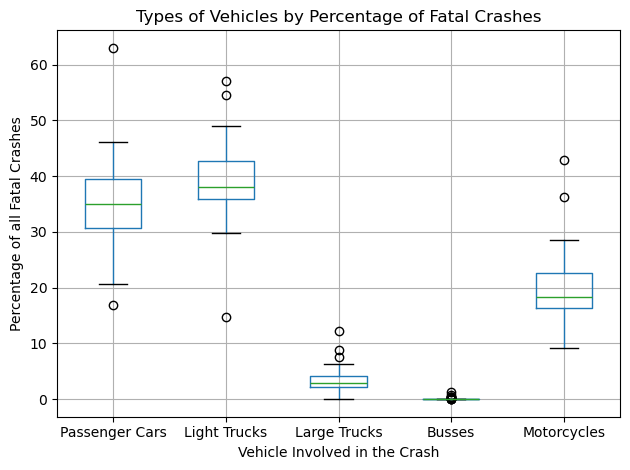

In [22]:
car_type = ["Passenger Car", "Light Truck", "Large Truck", "Bus", "Motorcycle"]
vehicle_percentages = vehicles[["Vehicle: Passenger Cars Percent", "Vehicle: Light Trucks Percent", "Vehicle: Large Trucks Percent", "Vehicle: Buses Percent", "Vehicle: Motorcycles Percent"]]
vehicle_percentages = vehicle_percentages.rename(columns = {"Vehicle: Passenger Cars Percent": "Passenger Cars", "Vehicle: Light Trucks Percent": "Light Trucks", "Vehicle: Large Trucks Percent": "Large Trucks", "Vehicle: Buses Percent": "Busses", "Vehicle: Motorcycles Percent": "Motorcycles"})
vehicle_percentages.boxplot()
plt.title("Types of Vehicles by Percentage of Fatal Crashes")
plt.ylabel("Percentage of all Fatal Crashes")
plt.xlabel("Vehicle Involved in the Crash")
plt.tight_layout()
plt.show()

**Interpretation**

- Light trucks appear to make up the greatest percent of fatal accidents.
- There is a greater variation in the total percentage of fatal accidents for passenger cars. This suggests that different states have different qualities of drivers or safer laws in place to protect their average car.
- Large trucks and busses always seem to make up a very small portion of the total percentage. It is worth noting that vehicles are much less common on the road though, and this could account for the low rate of fatal crashes.
- Motorcyclists, although less common, still make up a sizeable portion of all fatal crashes. This is particularly evident in two different states, as the boxplot shows outliers as high as 40% of fatal accidents involving motorcycles.


**Description**

 - In a vehicle collision, who is more likely to survive? A drunk driver, or a sober driver? At each blood alchohol concentration group (BAC), the boxplot below takes the difference between the percentage of drivers that survived and the percentage of drivers that died. These values were obtained by subtracting the percentages listed in the surviving driver BAC dataset and the killed driver BAC dataset. Luckily, these datasets had similar sizes so this approach is valid.

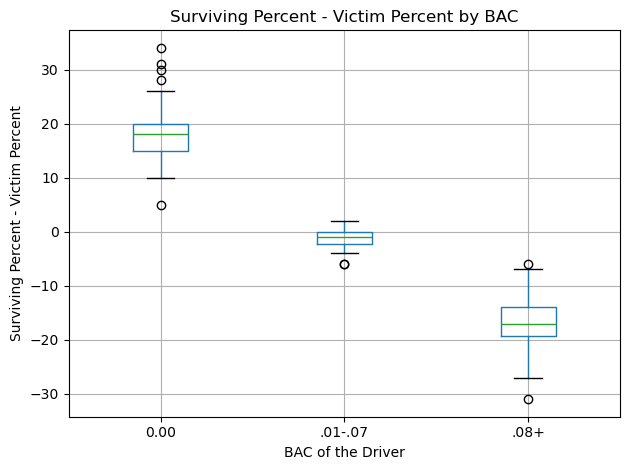

In [23]:
driver_living_percent = living_driver_bac[["Survivor BAC = 0.00 Percent", "Survivor BAC = .01--.07 Percent", "Survivor BAC = .08+ Percent"]] 
driver_victim_percent = driver_victim_bac[["Victim BAC = 0.00 Percent", "Victim BAC = .01--.07 Percent", "Victim BAC = .08+ Percent"]]
difference_percent = pd.DataFrame([driver_living_percent["Survivor BAC = 0.00 Percent"] - driver_victim_percent["Victim BAC = 0.00 Percent"], driver_living_percent["Survivor BAC = .01--.07 Percent"] - driver_victim_percent["Victim BAC = .01--.07 Percent"], driver_living_percent["Survivor BAC = .08+ Percent"] - driver_victim_percent["Victim BAC = .08+ Percent"]])
difference_percent = difference_percent.transpose()
difference_percent.columns = ["0.00", ".01-.07", ".08+"]
difference_percent.boxplot()
plt.title("Surviving Percent - Victim Percent by BAC")
plt.xlabel("BAC of the Driver")
plt.ylabel("Surviving Percent - Victim Percent")
plt.tight_layout()
plt.show()

**Interpretation**

 - Drivers with a BAC of 0.00 are much more likely to survive a crash than any other BAC.
 - We cannot determine if drivers with a BAC of 0.01--0.07 are more or less likely to survive
 - Drivers over the legal driving limit of .08 are significantly less likely to survive a crash than their sober counterparts.

**Description**

 - This boxplot compares restraint use with total percent of vehicle occupant death.

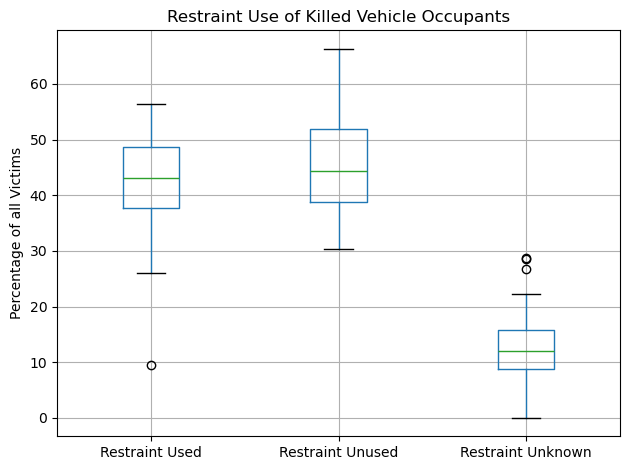

In [46]:
restraint_type = ["Restraint Used", "Restraint Unused", "Unknown"]
restrained = restraints[["Restraint Used Percent", "Restraint Not Used Percent", "Restraint Use Unknown Percent"]][:-1]
restrained = restrained.rename(columns = {"Restraint Used Percent": "Restraint Used", "Restraint Not Used Percent": "Restraint Unused", "Restraint Use Unknown Percent": "Restraint Unknown"})
restrained.boxplot()
plt.title("Restraint Use of Killed Vehicle Occupants")
plt.ylabel("Percentage of all Victims")
plt.tight_layout()
plt.show()

**Interpretation**

 - There are similar amounts of deaths between those who used restraints and those who didn't. Howver, the maximum percentage of total occupant death for those who didn't use restraints is 10% higher than those who did use restraints.
  - There are many cases in which the restraint use of the occupant is unknown.

# Key Findings

Using the visualizations shown above, we obtain the following results.

- Light trucks and passenger cars are the vehicles most likely to be in a fatal crash.
- People with a BAC of 0.00 are much more likely to survive then those with a BAC of 0.08+.
- There is no significant difference in fatality rates between those who used seatbelts and those who didn't.


# Limitations

However, there is one glaring weakness in the analysis of vehicle types and restraint use. The percentage of the population that drives passenger cars or light trucks is significantly higher than other types of vehicles. Similarly, more of the population wears seatbelts than not. Therefore we must take this into account in our analysis. Another weakness in the analysis is that results obtained from boxplots do not imply causation. We will correct the first limitation in the next section.

# More Visualizations

**Description**

- This boxplot examines the fatal crashrate per 100 vehicle miles traveled. The graph now accounts for use rate of vehicles. Note that busses are no longer included in the graph. Considering that busses are not commonly used civilian vehicles, they were deemed unnecessary from this point forward.

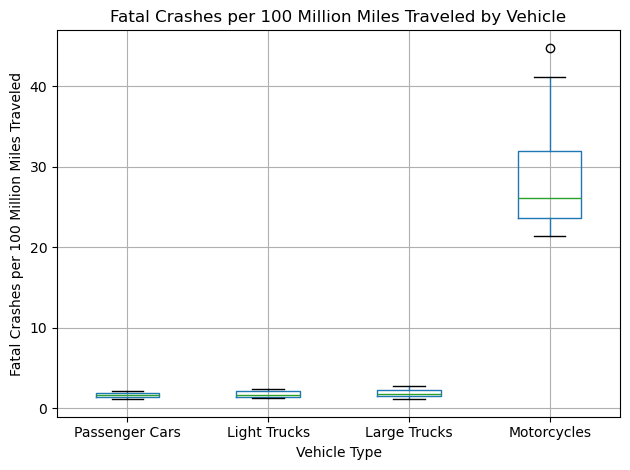

In [27]:
vmt_by_vehicle = vmt2[["Involvement Rate per 100 Million VMT", "Involvement Rate per 100 Million VMT1", "Involvement Rate per 100 Million VMT2", "Involvement Rate per 100 Million VMT3"]]
vmt_by_vehicle = vmt_by_vehicle.rename(columns={"Involvement Rate per 100 Million VMT": "Passenger Cars", "Involvement Rate per 100 Million VMT1": "Light Trucks", "Involvement Rate per 100 Million VMT2": "Large Trucks", "Involvement Rate per 100 Million VMT3": "Motorcycles"})
vmt_by_vehicle.boxplot()
plt.title("Fatal Crashes per 100 Million Miles Traveled by Vehicle")
plt.xlabel("Vehicle Type")
plt.ylabel("Fatal Crashes per 100 Million Miles Traveled")
plt.tight_layout()
plt.show()

**Interpretation**

- There is no significant difference in the fatal crash rates of cars and trucks of all varieties. 
- This graph now shows that motorcycles have a clear increase in fatal crashes as compared to other vehicles.

**Description**

 - This bar chart shows the average fatal crashes per 100 million miles traveled much better than the boxplot. We have discounted motorcycles for this chart.

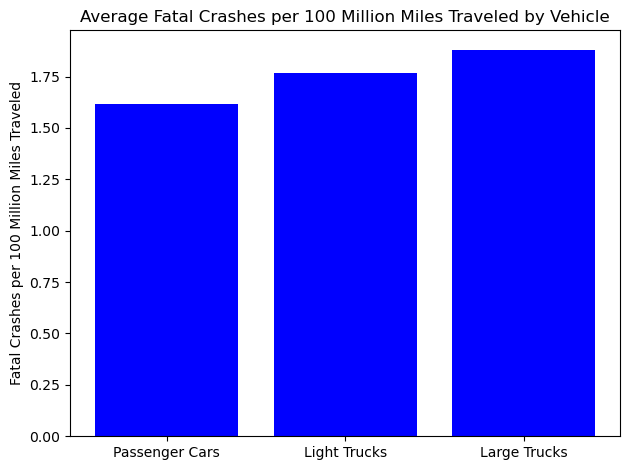

In [36]:
means = vmt_by_vehicle.mean()
vehicle_type = ["Passenger Cars", "Light Trucks", "Large Trucks"]
plt.bar(vehicle_type, means[0:3], color="blue")
plt.title("Average Fatal Crashes per 100 Million Miles Traveled by Vehicle")
plt.ylabel("Fatal Crashes per 100 Million Miles Traveled")
plt.tight_layout()
plt.show()

**Description**

 - The NHTSA estimates that 91.2% of Americans used seatbelts in passenger vehicles in 2024. We use that number to weight the number of fatal crashes based on restraints in the boxplot below.

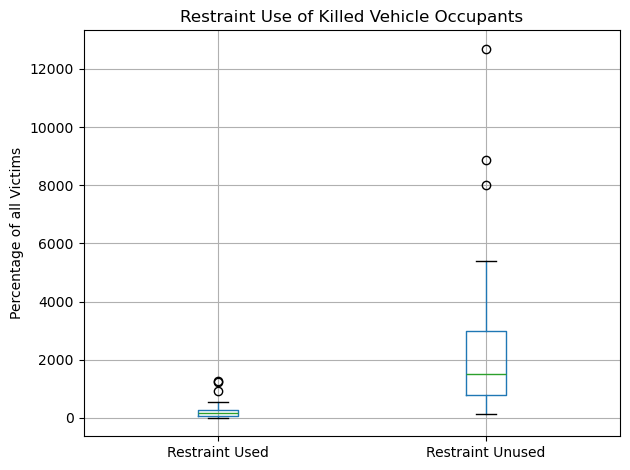

In [ ]:
restraint_type = ["Restraint Used", "Restraint Unused"]
restrained = restraints[["Restraint Used Number", "Restraint Not Used Number"]][:-1]
restrained["Restraint Used Number"] = restrained["Restraint Used Number"]/.912
restrained["Restraint Not Used Number"] = restrained["Restraint Not Used Number"]/.088
restrained = restrained.rename(columns = {"Restraint Used Number": "Restraint Used", "Restraint Not Used Number": "Restraint Unused"})
restrained.boxplot()
plt.title("Restraint Use of Killed Vehicle Occupants")
plt.ylabel("Weighted Number of all Victims")
plt.tight_layout()
plt.show()

**Interpretation**

- When considering the proportion of the population that uses seatbelts, it is evident that there is a much greater average number of people who died in crashes who were not wearing their seatbelts.
- Additionally, the variance is much larger when restraints are unused, which aligns with the earlier thought that some states are better at road safety than others.

# Conclusion

Answer the research question directly.

Example:

- There appears to be a **moderate relationship between sleep duration and depression prevalence**
- Further analysis using regression models could explore this relationship more rigorously


# Citations

- National Highway Traffic Safety Administration: https://www-fars.nhtsa.dot.gov/States/StatesOccupants.aspx
- ChatGPT
- Pandas Assistance: https://tutorialreference.com/python/examples/faq/python-pandas-how-to-convert-entire-dataframe-to-numeric-integers-or-floats


## Additional Notes From Class

- The notebook is a critical piece of communication, don't neglect it
- The notebook needs to be easily accessible. Your audience may not be experts in your field and/or the code you've written.
- The notebook needs to be able to run from top-to-bottom.
- Every major step should include **formatted** markdown explaining what you are doing and why.
- This notebook will contain more analyses than you will put in your presentation.
    - That said, remove code that isn't useful or that you were just testing.
- Use meaningful variable names, especially important when you're modifying whole dataframes.
- Label plots, don't rely on defaults
    - Add units to your axes labels if known.